In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Setup OK")

Setup OK


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AnalystLab_Week1/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Shape: {df.shape[0]} lignes x {df.shape[1]} colonnes")
df.head()

Shape: 7043 lignes x 21 colonnes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
# Vérifier les valeurs nulles "officielles"
print("=== Valeurs nulles par colonne ===")
print(df.isnull().sum())
print(f"\nTotal: {df.isnull().sum().sum()} valeurs nulles")

# Vérifier les doublons
print(f"\n=== Doublons ===")
print(f"Lignes dupliquées: {df.duplicated().sum()}")
print(f"customerID dupliqués: {df['customerID'].duplicated().sum()}")

=== Valeurs nulles par colonne ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total: 0 valeurs nulles

=== Doublons ===
Lignes dupliquées: 0
customerID dupliqués: 0


In [ ]:
# Tentative de conversion en numérique
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Combien de lignes deviennent NaN après conversion ?
print(f"Valeurs NaN après conversion: {df['TotalCharges'].isnull().sum()}")

# Afficher ces lignes problématiques
df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Valeurs NaN après conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [ ]:
# Remplacer les 11 NaN par 0 (clients nouveaux, rien facturé encore)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Vérification finale
print(f"Valeurs nulles restantes dans TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Type de TotalCharges maintenant: {df['TotalCharges'].dtype}")

Valeurs nulles restantes dans TotalCharges: 0
Type de TotalCharges maintenant: float64


In [ ]:
df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,0.16
std,24.56,30.09,2266.79,0.37
min,0.00,18.25,0.00,0.00
25%,9.00,35.50,398.55,0.00
50%,29.00,70.35,1394.55,0.00
75%,55.00,89.85,3786.60,0.00
max,72.00,118.75,8684.80,1.00


In [ ]:
print("=== Répartition du Churn ===")
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

=== Répartition du Churn ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
print("=== Genre ===")
print(df['gender'].value_counts())

print("\n=== Senior Citizen ===")
print(df['SeniorCitizen'].value_counts(normalize=True).round(3) * 100)

print("\n=== Type de contrat ===")
print(df['Contract'].value_counts())

print("\n=== Service Internet ===")
print(df['InternetService'].value_counts())

print("\n=== Méthode de paiement ===")
print(df['PaymentMethod'].value_counts())

=== Genre ===
gender
Male      3555
Female    3488
Name: count, dtype: int64

=== Senior Citizen ===
SeniorCitizen
0    83.8
1    16.2
Name: proportion, dtype: float64

=== Type de contrat ===
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

=== Service Internet ===
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

=== Méthode de paiement ===
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [ ]:
# Tableau croisé : pour chaque type de contrat, quelle proportion churn ?
churn_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(churn_contract.round(1))

Churn             No   Yes
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


In [ ]:
churn_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(churn_internet.round(1))

Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.1  41.9
No               92.6   7.4


In [ ]:
churn_payment = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
print(churn_payment.round(1))

Churn                        No   Yes
PaymentMethod                        
Bank transfer (automatic)  83.3  16.7
Credit card (automatic)    84.8  15.2
Electronic check           54.7  45.3
Mailed check               80.9  19.1


In [ ]:
churn_senior = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100
print(churn_senior.round(1))

Churn            No   Yes
SeniorCitizen            
0              76.4  23.6
1              58.3  41.7


In [ ]:
print(df.groupby('Churn')['tenure'].describe().round(2))

        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [ ]:
print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

        count   mean    std    min    25%    50%   75%     max
Churn                                                         
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.4  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.2  118.35


In [ ]:
# On crée une version numérique de Churn (0 = No, 1 = Yes) pour pouvoir la corréler
plot_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
plot_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

corr = plot_df.corr()
print(corr.round(2))

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen  \
tenure            1.00            0.25          0.83           0.02   
MonthlyCharges    0.25            1.00          0.65           0.22   
TotalCharges      0.83            0.65          1.00           0.10   
SeniorCitizen     0.02            0.22          0.10           1.00   
Churn_binary     -0.35            0.19         -0.20           0.15   

                Churn_binary  
tenure                 -0.35  
MonthlyCharges          0.19  
TotalCharges           -0.20  
SeniorCitizen           0.15  
Churn_binary            1.00  


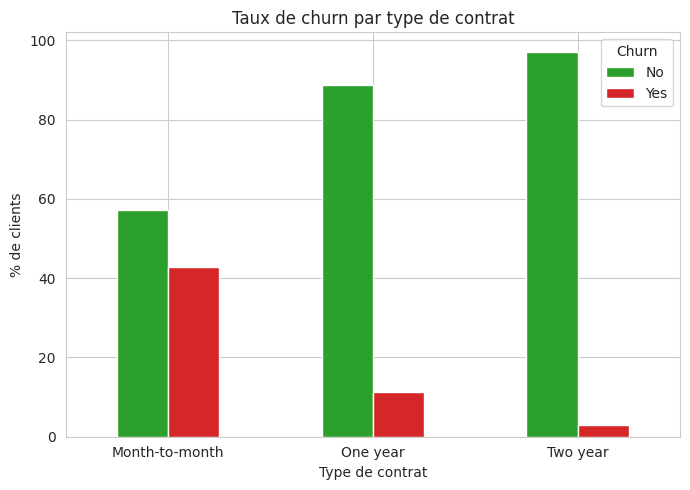

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#2ca02c','#d62728'])

ax.set_title('Taux de churn par type de contrat')
ax.set_ylabel('% de clients')
ax.set_xlabel('Type de contrat')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

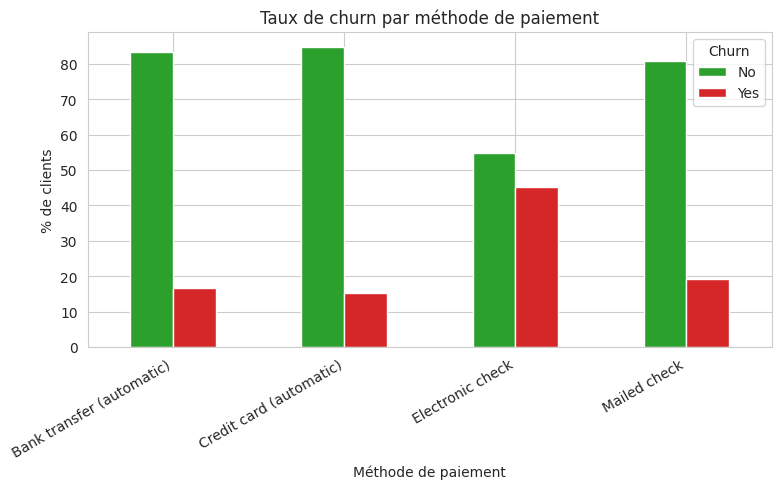

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
ct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#2ca02c','#d62728'])

ax.set_title('Taux de churn par méthode de paiement')
ax.set_ylabel('% de clients')
ax.set_xlabel('Méthode de paiement')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

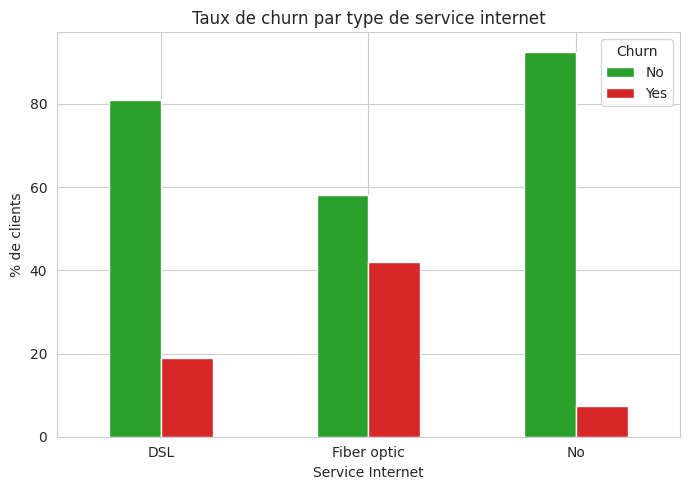

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#2ca02c','#d62728'])

ax.set_title('Taux de churn par type de service internet')
ax.set_ylabel('% de clients')
ax.set_xlabel('Service Internet')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

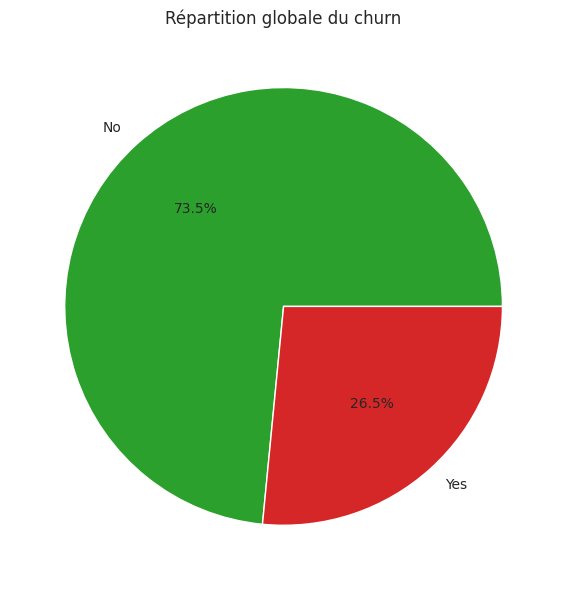

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2ca02c','#d62728'], ax=ax)

ax.set_title('Répartition globale du churn')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

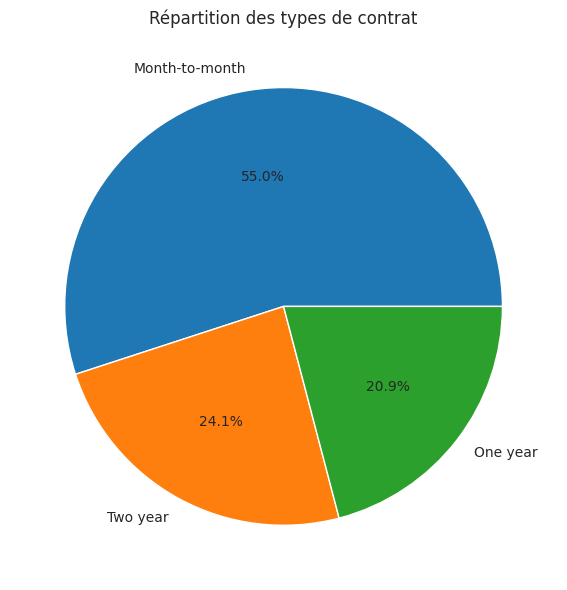

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
df['Contract'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#1f77b4','#ff7f0e','#2ca02c'], ax=ax)

ax.set_title('Répartition des types de contrat')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

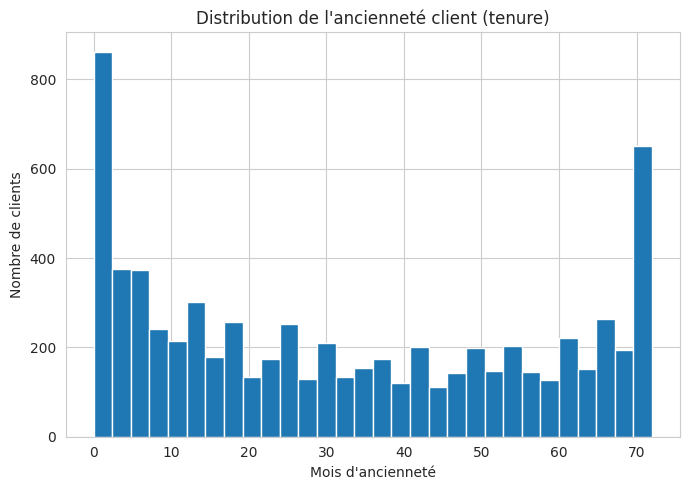

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(df['tenure'], bins=30, color='#1f77b4', edgecolor='white')

ax.set_title("Distribution de l'ancienneté client (tenure)")
ax.set_xlabel('Mois d\'ancienneté')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

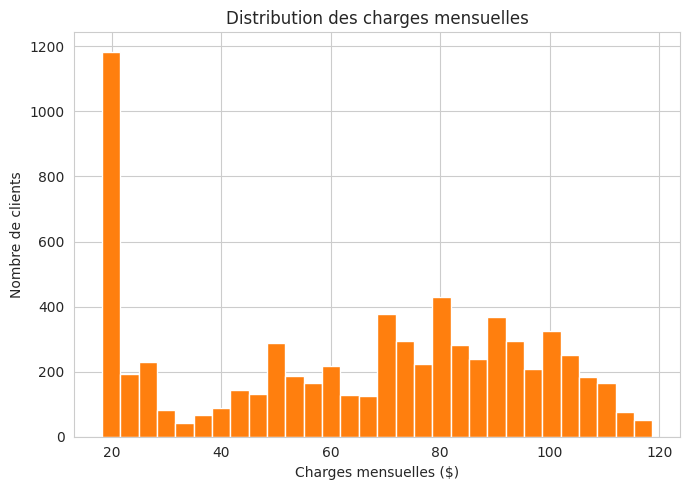

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
ax.hist(df['MonthlyCharges'], bins=30, color='#ff7f0e', edgecolor='white')

ax.set_title('Distribution des charges mensuelles')
ax.set_xlabel('Charges mensuelles ($)')
ax.set_ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

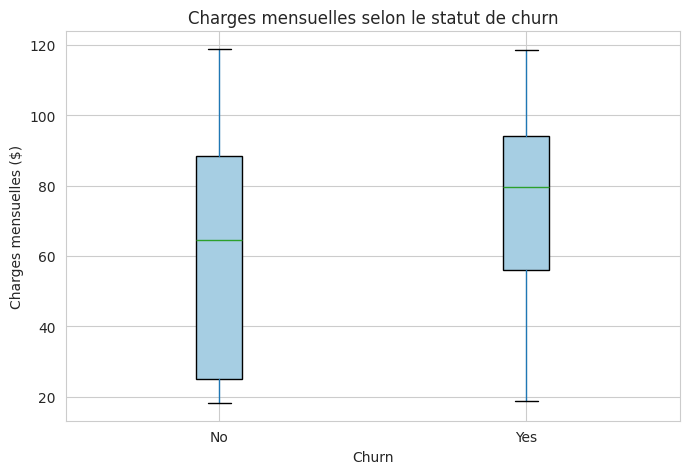

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='#a6cee3'))

ax.set_title('Charges mensuelles selon le statut de churn')
plt.suptitle('')  # supprime le titre automatique moche que pandas ajoute
ax.set_xlabel('Churn')
ax.set_ylabel('Charges mensuelles ($)')
plt.tight_layout()
plt.show()

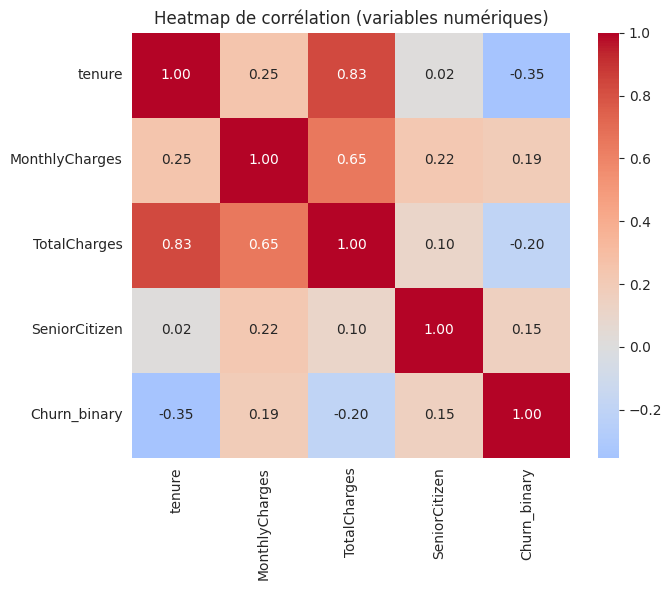

In [ ]:
plot_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].copy()
plot_df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)
corr = plot_df.corr()

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)

ax.set_title('Heatmap de corrélation (variables numériques)')
plt.tight_layout()
plt.show()

## Part 4 — Business Insights

### Cinq insights clés

1. **Le type de contrat est le facteur dominant du churn.** Les clients Month-to-month churnent à 42,7%, contre 2,8% pour les contrats de deux ans — un écart de 15x. C'est le levier le plus puissant à disposition d'ABC Communications.

2. **La première année est la fenêtre de rétention critique.** Les clients qui churnent ont une ancienneté médiane de seulement 10 mois, contre 38 mois pour les clients fidèles. Un quart des churners partent dans les 2 premiers mois.

3. **Le fiber optic est paradoxalement à haut risque.** Malgré être le service premium, il churn à 41,9% — plus du double du DSL (19,0%). Ceci pointe vers un problème de prix ou de qualité perçue, pas un manque de demande.

4. **La méthode de paiement reflète (et renforce) le risque de churn.** Les utilisateurs d'Electronic check churnent à 45,3%, près de 3x plus que les méthodes automatiques (15-17%).

5. **Les seniors sont un segment restreint mais très vulnérable.** Seulement 16% de la base, mais 41,7% de churn contre 23,6% pour les non-seniors — près du double.

### Trois risques business

1. **Concentration du revenu dans le segment le plus à risque.** 55% des clients sont en Month-to-month — perdre ce segment érode le revenu récurrent plus vite que les nouvelles souscriptions ne peuvent compenser.
2. **Le produit premium sous-performe sur la rétention.** Si le churn du fiber optic n'est pas traité, ABC risque un dommage réputationnel qui compromet les futures montées en gamme.
3. **L'attrition précoce gaspille le coût d'acquisition.** Les clients qui partent avant leur premier anniversaire n'ont probablement pas encore généré assez de revenu pour couvrir leur coût d'acquisition.

### Trois opportunités business

1. **Campagnes de migration contractuelle.** Inciter les clients Month-to-month à passer sur un contrat annuel ou biennal pourrait réduire significativement le churn.
2. **Pousser l'automatisation des paiements.** Encourager les utilisateurs d'Electronic check à basculer vers un paiement automatique réduirait à la fois le churn et la charge administrative.
3. **Programme de rétention pour la première année.** Un suivi structuré durant les 0-12 premiers mois pourrait traiter la cause principale de perte avant qu'elle ne survienne.

## Part 5 — Business Recommendations

1. **Lancer une incitation à la mise à niveau contractuelle.** Offrir aux clients Month-to-month une réduction (10-15%) ou un avantage (bundle streaming) pour migrer vers un contrat 1 ou 2 ans, en priorisant les clients ayant déjà 6+ mois d'ancienneté.

2. **Construire un programme de rétention "90 jours".** Suivi proactif, enquêtes de satisfaction et support renforcé durant les 3 premiers mois, période où le risque de churn est le plus élevé.

3. **Investiguer la qualité du service fiber optic.** Mener une enquête de satisfaction ciblée auprès des abonnés fiber pour isoler si le churn vient du prix, de la fiabilité, ou du service client — puis agir sur la cause racine.

4. **Inciter la migration vers les paiements automatiques.** Offrir une petite réduction ou un crédit pour passer d'Electronic check à un prélèvement automatique ou une carte de crédit.

5. **Créer un parcours de rétention dédié aux seniors.** Vu leur taux de churn disproportionné, une ligne de support dédiée, une facturation simplifiée, ou une offre de fidélité spécifique pourrait réduire significativement l'attrition dans ce segment.

6. **Déployer un score de risque de churn.** Utiliser les variables identifiées ici (contrat, tenure, service internet, méthode de paiement) comme signaux d'alerte précoce pour l'équipe de rétention.

---

## Conclusion

Cette analyse identifie la flexibilité contractuelle, la faible ancienneté, le service fiber optic et les méthodes de paiement manuelles comme les quatre principaux facteurs de churn pour ABC Communications Ltd. Les recommandations ci-dessus ciblent directement ces leviers, priorisées par impact attendu relatif à l'effort de mise en œuvre.